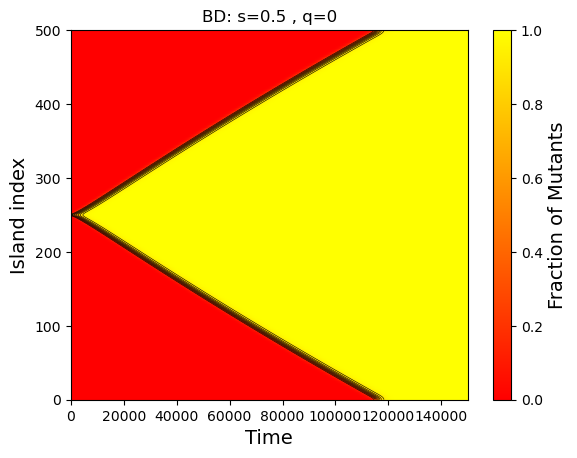

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 1
K = 500
delta_t = 1 / (N*K)
delta_x = 1 / K
D = 1 / (2 * (K**2))
t = 150000
s = 0.5
q = 0

# Initial state
Phi = np.zeros(K)
Phi[K // 2] = 1 / N
Phi_bar = Phi.sum() / (K * 2)

speed_BD = [0]
history = [Phi.copy()]

for time in range(t):
    # Vectorized laplacian with periodic BC
    laplacian = (np.roll(Phi, -1) + np.roll(Phi, 1) - 2 * Phi) / delta_x**2

    # BD dynamics update rule
    denom_factor = q * (D * laplacian + 2 * Phi) + 1
    denom_factor = np.maximum(denom_factor, 1e-1)  # element-wise floor

    numer = D * ((1 + s) - (s - q) * Phi) * laplacian + (s - q) * Phi * (1 - Phi)
    denom = (1 + s * Phi_bar) * denom_factor

    Phi = Phi + delta_t * numer / denom

    prev_Phi_bar = Phi_bar
    Phi_bar = Phi.sum() / (K * 2)
    speed_BD.append(Phi_bar - prev_Phi_bar)
    history.append(Phi.copy())

# ── Plotting ──────────────────────────────────────────────────────────────────
history_arr = np.array(history).T  # shape (K, t+1)

w_BD = history_arr.sum(axis=0) / K

plt.pcolormesh(history_arr, cmap="autumn", vmax=1)
cbar = plt.colorbar()
cbar.set_label('Fraction of Mutants', fontsize=14)
plt.contour(history_arr, [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
            colors='black', linewidths=0.4)

plt.title(f'BD: s={s} , q={q}')
plt.xlabel('Time', fontsize=14)
plt.ylabel('Island index', fontsize=14)
plt.show()

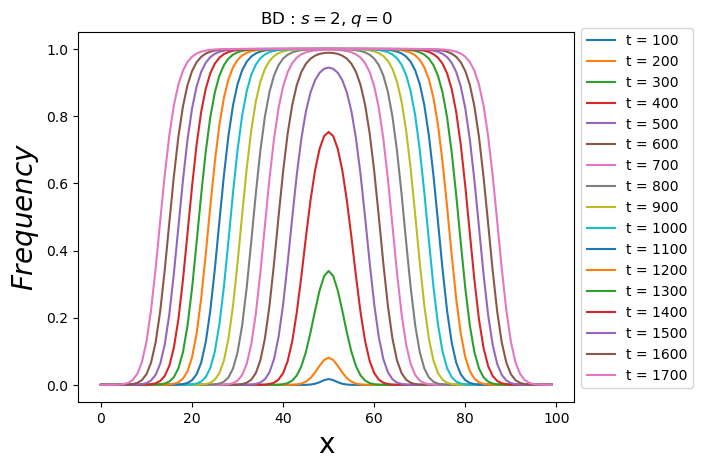

In [8]:
l = np.arange(K)  # island indices
o = np.arange(100, 1800, 100)

for m in o:
    plt.plot(l, history_arr[:, m], label=f"t = {m}")

plt.title(f'BD : $s = ${s}, $q=${q}')
plt.legend(bbox_to_anchor=(1, 1.03))
plt.xlabel('x', fontsize=20)
plt.ylabel('$Frequency$', fontsize=20)
plt.show()

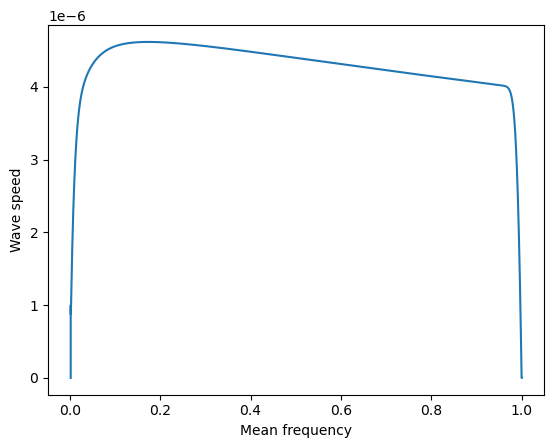

In [9]:
plt.plot(w_BD, speed_BD , label = "BD")
plt.xlabel('Mean frequency')
plt.ylabel('Wave speed')

plt.show()

In [10]:
speed_BD = np.save("speed_BD_1000_s=05,q=0.npy",speed_BD)
w_BD = np.save("w_BD_1000_s=05,q=0.npy",w_BD)